# Part 3: Cluster evaluation and visualization

Quantitatively and qualitatively assess the clustering on the music feature space: load artifacts, fit/reuse KMeans, compute sanity metrics, inspect clusters, and visualize the space.

### Table of contents:
- [3.1 Setup and data loading](#31-setup-and-data-loading)
- [3.2 Fit KMeans clusters](#32-fit-kmeans-clusters)
- [3.3 Silhouette](#33-silhouette)
- [3.4 Purity / NMI / ARI against provided genres](#34-purity--nmi--ari-against-provided-genres)
- [3.5 Cluster summaries](#35-cluster-summaries)
- [3.6 Tags and representative tracks](#36-tags-and-representative-tracks)
- [3.7 PCA](#37-pca)
- [3.8 t-SNE](#38-t-sne)
- [3.9 UMAP](#39-umap)
- [3.10 LSH recall and latency check](#310-lsh-recall-and-latency-check)
- [3.11 LSH recall vs speed plots](#311-lsh-recall-vs-speed-plots)
- [3.12 Conclusion](#312-conclusion)


## 3.1 Setup and data loading

We reload the cleaned dataset and weighted feature matrix from `artifacts/`. Align common track IDs so features and metadata stay in sync. Build `X_main` as the numpy matrix we will cluster and query for neighbors. Keep `full_df` around for genres, tags, and track names when interpreting clusters.

In [50]:
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42

notebook_dir = Path.cwd().resolve()
project_root = notebook_dir
while not (project_root / "artifacts").exists() and project_root.parent != project_root:
    project_root = project_root.parent

artifact_dir = project_root / "artifacts"

full_df_path = artifact_dir / "final_cleaned_dataset.csv"
features_npz_path = artifact_dir / "track_features.npz"

for path in [full_df_path, features_npz_path]:
    if not path.exists():
        raise FileNotFoundError(path)

full_df = pd.read_csv(full_df_path)
features_npz = np.load(features_npz_path, allow_pickle=True)
track_ids = features_npz["track_ids"].astype(str)
weighted_features = features_npz["features_weighted"]

# Align rows so X_main matches full_df order
trackid_to_idx = {tid: i for i, tid in enumerate(track_ids)}
full_df["track_id"] = full_df["track_id"].astype(str)
full_df = full_df[full_df["track_id"].isin(trackid_to_idx)].reset_index(drop=True)
row_order = full_df["track_id"].map(trackid_to_idx).to_numpy()
X_main = weighted_features[row_order].astype(np.float32)

full_df.head()


,track_id,artists,track_name,track_genre,search_string,duration_ms,tempo,tempo_log,duration_minutes,tags_clean_text,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lfm_playcount,lfm_listeners,log_playcount,log_listeners,log_plays_per_listener,plays_per_listener,tag_count
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),dance,"Unholy (feat. Kim Petras) - Sam Smith, Kim Petras",156943,131.121,4.876121,2.615717,pop hyperpop electropop electronic pop rap,0.01300,0.714,0.472,0.000005,0.2660,-7.375,0.0864,0.238,10995250.0,920570.0,16.212974,13.732749,2.560629,11.943959,5
1,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),dance,"I'm Good (Blue) - David Guetta, Bebe Rexha",175238,128.040,4.852343,2.920633,house electronic dance electro house 2022,0.00383,0.561,0.965,0.000007,0.3710,-3.673,0.0343,0.304,7924612.0,758980.0,15.885484,13.539732,2.437215,10.441134,5
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,latin,La Bachata - Manuel Turizo,162637,124.980,4.828154,2.710617,reggaeton latin pop latin pop latino bachata male vocalist colombian pop colombia colombian,0.58300,0.835,0.679,0.000002,0.2180,-5.329,0.0364,0.850,4325531.0,365331.0,15.280046,12.808562,2.552568,11.840033,10
3,6Sq7ltF9Qa7SNFBsV5Cogx,Bad Bunny;Chencho Corleone,Me Porto Bonito,latin,"Me Porto Bonito - Bad Bunny, Chencho Corleone",178567,92.005,4.521843,2.976117,bad bunny reggaeton fire latin chencho corleone,0.09010,0.911,0.712,0.000027,0.0933,-5.105,0.0817,0.425,8928528.0,632558.0,16.004762,13.357529,2.715685,14.114955,5
4,5Eax0qFko2dh7Rl2lYs3bx,Bad Bunny,Efecto,latin,Efecto - Bad Bunny,213061,98.047,4.585447,3.551017,reggaeton latin,0.14100,0.801,0.475,0.000017,0.0639,-8.797,0.0516,0.234,6119925.0,420681.0,15.627061,12.949632,2.743910,14.547662,2


## 3.2 Fit KMeans clusters

Use the number of distinct genres as `n_clusters` to mirror the setup we have in part 1. Fit KMeans on the full feature space and attach the label column to `full_df`. Cluster sizes printed here give a quick sense of balance or dominance.

In [51]:
from sklearn.cluster import KMeans

n_clusters = full_df["track_genre"].nunique()
print("Number of distinct genres:", n_clusters)

kmeans_main = KMeans(
    n_clusters=n_clusters,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE,
)

cluster_labels = kmeans_main.fit_predict(X_main)
full_df["cluster_kmeans_main"] = cluster_labels

cluster_sizes = full_df["cluster_kmeans_main"].value_counts().sort_index()
cluster_sizes.head()

Number of distinct genres: 113


0     510
1    1007
2     573
3     704
4     695
Name: cluster_kmeans_main, dtype: int64

## 3.3 Silhouette

In the Silhouette, we meassure the internal cohesion and separation. We do the entire dataset to estimate silhouette, even though it has quadratic run time, it's okay with this amount of data: higher is tighter separation, near zero means overlap, negative means misplacement. The histogram helps spot whether most points are borderline or if there is a clean core. This is an internal metric, independent of genre labels.

In [52]:
from sklearn.metrics import silhouette_score

silhouette_full = silhouette_score(
    X_main,
    full_df["cluster_kmeans_main"].to_numpy(),
    metric="cosine",
)
print(f"Silhouette score (n={len(X_main)}): {silhouette_full:.3f}")


Silhouette score (n=55129): 0.331


Silhouette score (n=55129): 0.331


count    55129.000000
mean         0.331140
std          0.329711
min         -0.926192
25%          0.117316
50%          0.355530
75%          0.582197
max          0.991428
dtype: float64

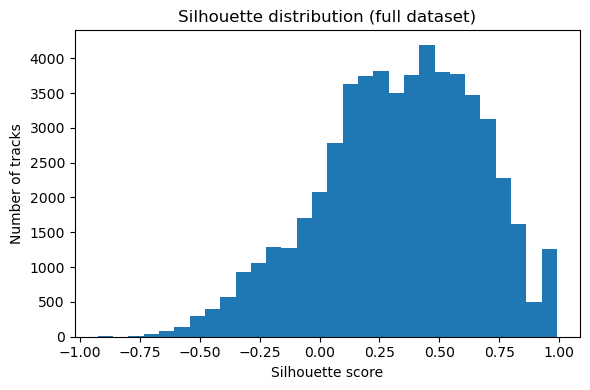

In [53]:
from sklearn.metrics import silhouette_score, silhouette_samples
import pandas as pd
import matplotlib.pyplot as plt

labels_full = full_df["cluster_kmeans_main"].to_numpy()
silhouette_full = silhouette_score(X_main, labels_full, metric="cosine")
silhouette_full_vals = silhouette_samples(X_main, labels_full, metric="cosine")

print(f"Silhouette score (n={len(X_main)}): {silhouette_full:.3f}")
display(pd.Series(silhouette_full_vals).describe())

plt.figure(figsize=(6, 4))
plt.hist(silhouette_full_vals, bins=30)
plt.xlabel("Silhouette score")
plt.ylabel("Number of tracks")
plt.title("Silhouette distribution (full dataset)")
plt.tight_layout()
plt.show()


Silhouette on all 55k tracks is 0.33: moderate separation. Most points are clearly positive (median 0.36, 75% 0.58) with a small negative tail down to -0.93, so clusters are meaningful but still partially overlapping and fuzzy at the boundaries.

## 3.4 Purity / NMI / ARI against provided genres

Compare discovered clusters against the given `track_genre` labels. Purity captures majority agreement, NMI/ARI capture mutual information and pairwise agreement; higher values mean clusters align better with genres. Treat this as a sanity check rather than the only success metric.

In [54]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

genres = full_df["track_genre"].fillna("unknown").astype(str)
clusters = full_df["cluster_kmeans_main"].to_numpy()

crosstab = pd.crosstab(clusters, genres)

majority_counts = crosstab.max(axis=1)
purity = majority_counts.sum() / len(full_df)

nmi = normalized_mutual_info_score(genres, clusters)
ari = adjusted_rand_score(genres, clusters)

print(f"Overall purity: {purity:.3f}")
print(f"NMI (clusters vs. track_genre): {nmi:.3f}")
print(f"ARI (clusters vs. track_genre): {ari:.3f}")

Overall purity: 0.471
NMI (clusters vs. track_genre): 0.585
ARI (clusters vs. track_genre): 0.241


Purity 0.47 with NMI 0.58 and ARI 0.23 means clusters capture some genre signal but are far from one-genre buckets. Many clusters mix genres; mutual information is moderate and pairwise agreement is low. We should treat genre alignment as partial: good enough for rough grouping, not for strict genre labeling

## 3.5 Cluster summaries

Here we summarize each cluster with mean feature values and size to see broad “profiles” (energy, acousticness, speechiness, etc.). Sort by size to review the largest groups first. Use this to spot outliers (e.g., very high instrumentalness or extreme loudness).

In [55]:
numeric_cols_candidate = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "liveness",
    "loudness",
    "speechiness",
    "valence",
    "tempo_log",
    "duration_minutes",
    "log_playcount",
    "log_listeners",
    "log_plays_per_listener",
    "tag_count",
]

numeric_cols = [c for c in numeric_cols_candidate if c in full_df.columns]

cluster_summary = (
    full_df.groupby("cluster_kmeans_main")[numeric_cols]
    .mean()
    .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
    .sort_values("size", ascending=False)
)

cluster_summary.head(10)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,tempo_log,duration_minutes,log_playcount,log_listeners,log_plays_per_listener,tag_count,size
cluster_kmeans_main,,,,,,,,,,,,,,,
11,0.226232,0.664213,0.716524,0.087255,0.208790,-6.587004,0.104937,0.617465,4.883054,3.513853,8.246620,6.853579,1.644056,2.917753,3453
102,0.605705,0.585214,0.416760,0.143904,0.175766,-10.528253,0.071680,0.457351,4.612648,3.179496,7.997191,6.764171,1.519545,3.126188,2631
41,0.872606,0.320685,0.194631,0.798809,0.180785,-23.101086,0.053815,0.162779,4.581334,3.547972,8.682398,7.311857,1.647943,3.122782,1409
1,0.246209,0.706020,0.652933,0.130894,0.192329,-6.960384,0.179385,0.524923,4.728225,3.309149,10.637442,8.827027,1.982616,7.349553,1007
88,0.166525,0.511120,0.722770,0.045073,0.189462,-6.391361,0.056562,0.478245,4.804406,3.697908,13.034561,11.145039,2.041354,8.639098,931
105,0.338399,0.585651,0.585563,0.099375,0.183162,-7.858198,0.059701,0.465245,4.790667,3.420929,12.426139,10.534184,2.042746,8.617450,894
104,0.511692,0.564641,0.470559,0.025878,0.173536,-9.292630,0.053763,0.431258,4.764828,3.674376,11.420781,9.753675,1.852807,8.725749,835
40,0.049679,0.456889,0.870710,0.027687,0.226758,-4.841491,0.074733,0.554038,4.902381,3.155941,10.584972,8.832384,1.921257,8.991432,817
81,0.358187,0.525600,0.549659,0.705251,0.163695,-12.837907,0.069642,0.296024,4.772047,4.542843,9.944005,8.665427,1.538042,9.604194,763


## 3.6 Tags and representative tracks

Here we extract most frequent tags per cluster and nearest-to-centroid tracks for quick listening candidates. This gives a qualitative feel for whether tags and exemplars match the numerical profile. Mixed tags or incoherent exemplars can flag messy clusters.

In [56]:
from collections import Counter

def top_tags_for_cluster(cluster_id, top_n=10):
    if "tags_clean_text" not in full_df.columns:
        return []
    mask = full_df["cluster_kmeans_main"] == cluster_id
    tags_series = full_df.loc[mask, "tags_clean_text"].fillna("")
    counter = Counter()
    for s in tags_series:
        if not s:
            continue
        for t in s.split():
            counter[t] += 1
    return counter.most_common(top_n)

first_cluster = int(cluster_summary.index[0])
top_tags_for_cluster(first_cluster, top_n=10)

[('pop', 491),
 ('rock', 343),
 ('rap', 253),
 ('electronic', 248),
 ('vocalist', 235),
 ('american', 230),
 ('all', 211),
 ('female', 183),
 ('metal', 144),
 ('latin', 142)]

In [57]:
from sklearn.metrics import pairwise_distances

def representative_tracks(cluster_id, top_n=5):
    mask = full_df["cluster_kmeans_main"] == cluster_id
    indices = np.where(mask.to_numpy())[0]
    if len(indices) == 0:
        return full_df.iloc[[]]

    center = kmeans_main.cluster_centers_[cluster_id]
    X_cluster = X_main[indices]
    dists = pairwise_distances(X_cluster, center.reshape(1, -1), metric="euclidean").ravel()
    order = np.argsort(dists)[:top_n]
    chosen = indices[order]
    return full_df.loc[chosen, ["track_id", "artists", "track_name", "track_genre"]]

representative_tracks(first_cluster, top_n=5)

,track_id,artists,track_name,track_genre
33740,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
20716,1HKAmEDrCjyXBP6rgCHq9i,Bijay Anand Sahu;Ayushi Pani,Amar Gaan,samba
21163,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
36926,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
42434,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids


In [58]:
def describe_cluster(cluster_id, top_n_tags=10, top_n_tracks=5):
    if "cluster_kmeans_main" not in full_df.columns:
        raise ValueError("cluster_kmeans_main not found; run clustering cell first.")

    mask = full_df["cluster_kmeans_main"] == cluster_id
    size = int(mask.sum())
    if size == 0:
        print(f"Cluster {cluster_id} has no rows.")
        return

    genres = full_df.loc[mask, "track_genre"].value_counts().head(5)
    means = full_df.loc[mask, numeric_cols].mean() if numeric_cols else pd.Series(dtype=float)

    print(f"Cluster {cluster_id}")
    print(f"Size: {size}")
    print("Top genres:")
    print(genres)
    print("Mean feature profile:")
    print(means.round(3))
    print("Top tags:")
    print(top_tags_for_cluster(cluster_id, top_n=top_n_tags))
    print("Representative tracks:")
    display(representative_tracks(cluster_id, top_n=top_n_tracks))

if "cluster_summary" not in globals():
    cluster_summary = (
        full_df.groupby("cluster_kmeans_main")[numeric_cols]
        .mean()
        .assign(size=lambda g: g.index.map(full_df["cluster_kmeans_main"].value_counts()))
        .sort_values("size", ascending=False)
    )

cluster_ids = list(cluster_summary.index[:5])
for cid in cluster_ids:
    describe_cluster(int(cid))


Cluster 11
Size: 3453
Top genres:
kids        310
malay       158
children    136
party       118
forro       118
Name: track_genre, dtype: int64
Mean feature profile:
acousticness              0.226
danceability              0.664
energy                    0.717
instrumentalness          0.087
liveness                  0.209
loudness                 -6.587
speechiness               0.105
valence                   0.617
tempo_log                 4.883
duration_minutes          3.514
log_playcount             8.247
log_listeners             6.854
log_plays_per_listener    1.644
tag_count                 2.918
dtype: float64
Top tags:
[('pop', 491), ('rock', 343), ('rap', 253), ('electronic', 248), ('vocalist', 235), ('american', 230), ('all', 211), ('female', 183), ('metal', 144), ('latin', 142)]
Representative tracks:


,track_id,artists,track_name,track_genre
33740,11CrYElJH7l26yy5Tb5Ihy,Matadoria,Vettam,malay
20716,1HKAmEDrCjyXBP6rgCHq9i,Bijay Anand Sahu;Ayushi Pani,Amar Gaan,samba
21163,0U7SRbyBhkdXdulXr3veKQ,Kevi Jonny,Aquele Story,forro
36926,6Eo1tU0Zw7Bgw3cPtVKxRX,Balek,112,party
42434,2uyYcVToGd0P3twslT6Qzn,DJ Black Rock,GDFR (Going Down for Real),kids


Cluster 102
Size: 2631
Top genres:
study          267
rock-n-roll    185
malay          166
honky-tonk     163
disney         139
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.606
danceability               0.585
energy                     0.417
instrumentalness           0.144
liveness                   0.176
loudness                 -10.528
speechiness                0.072
valence                    0.457
tempo_log                  4.613
duration_minutes           3.179
log_playcount              7.997
log_listeners              6.764
log_plays_per_listener     1.520
tag_count                  3.126
dtype: float64
Top tags:
[('country', 409), ('pop', 339), ('vocalist', 279), ('all', 229), ('los', 201), ('latin', 178), ('classic', 170), ('female', 162), ('male', 159), ('mexico', 158)]
Representative tracks:


,track_id,artists,track_name,track_genre
20516,3RDDPTFuikYlu0A4OXCCkl,Nicolas Candido,Hoje Caminhei,mpb
55061,4wTMYsUaXJFwT9CqA0TOzX,Nikolay Erdenko,Malen'kaja khora,romance
31281,1z9GHAYy5cSzeh4rRnafSN,Sonia Rivas,Con Tu Misma Moneda,rock-n-roll
15546,5qG6pu4Vq9f7wB0NAso4UN,King Shubh;King,Ghumshudaa (Lofi Flip) [feat. King],indian
54574,1IF1IpJ8SnBDgHO5Nig0pD,"Francisco, el Hombre",O TEMPO É SUA MORADA :: celebrar,mpb


Cluster 41
Size: 1409
Top genres:
sleep        354
classical    180
piano        146
disney       123
iranian      108
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.873
danceability               0.321
energy                     0.195
instrumentalness           0.799
liveness                   0.181
loudness                 -23.101
speechiness                0.054
valence                    0.163
tempo_log                  4.581
duration_minutes           3.548
log_playcount              8.682
log_listeners              7.312
log_plays_per_listener     1.648
tag_count                  3.123
dtype: float64
Top tags:
[('ambient', 289), ('classical', 259), ('piano', 176), ('composer', 157), ('electronic', 154), ('classic', 107), ('experimental', 102), ('romantic', 77), ('rock', 77), ('iranian', 73)]
Representative tracks:


,track_id,artists,track_name,track_genre
54910,1VsXbdekUKQ0KJIBaqC96E,Franz Schubert;Yanica Hristova,"4 Impromptus, Op. 90, D. 899: II. Allegro - Coda",classical
54550,6bpRlS4YiYLCsylFcLfX4m,Yiruma,Poem+,new-age
54902,4j63MsY1JhofTuai9FwWb3,Pyotr Ilyich Tchaikovsky;Una Bourne,"2 Pieces for Piano, Op. 10, TH 132: No. 2, Humoresque. Allegretto scherzando",classical
41907,5aQo0YEgGT3IEujA4Bj8kf,Piano Radiance,My Heart Will Go On,disney
54912,039sj87NWcViw10cfxBIsv,Edvard Grieg;Una Bourne,"Lyric Pieces III, Op. 43 (Excerpts): No. 6, Til foråret",classical


Cluster 1
Size: 1007
Top genres:
hip-hop    167
study      128
spanish     54
emo         50
turkish     40
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.246
danceability               0.706
energy                     0.653
instrumentalness           0.131
liveness                   0.192
loudness                  -6.960
speechiness                0.179
valence                    0.525
tempo_log                  4.728
duration_minutes           3.309
log_playcount             10.637
log_listeners              8.827
log_plays_per_listener     1.983
tag_count                  7.350
dtype: float64
Top tags:
[('hip-hop', 1616), ('rap', 1113), ('hop', 312), ('hip', 272), ('underground', 270), ('desi', 231), ('pop', 169), ('indian', 165), ('alternative', 164), ('experimental', 157)]
Representative tracks:


,track_id,artists,track_name,track_genre
27735,5Lh1pcMrQ6rycqwqs7abGY,Nowator,Co Tu Jest Grane,disco
28711,1mKoTwFGRzGr1qdXh9Sw81,MZ,On shoot,french
20667,1Je6kbDzxcqsVDdbVJSJB9,DJ Jamaika,Tô Só Observando,r-n-b
33136,66l80Z3ItK23K0zBuIOao2,Gata Cattana,El plan,spanish
15412,4ahdel2ygLNWN47cDexfwt,Ouse,You Make It Worse,emo


Cluster 88
Size: 931
Top genres:
alt-rock     151
power-pop    103
piano         80
acoustic      63
garage        50
Name: track_genre, dtype: int64
Mean feature profile:
acousticness               0.167
danceability               0.511
energy                     0.723
instrumentalness           0.045
liveness                   0.189
loudness                  -6.391
speechiness                0.057
valence                    0.478
tempo_log                  4.804
duration_minutes           3.698
log_playcount             13.035
log_listeners             11.145
log_plays_per_listener     2.041
tag_count                  8.639
dtype: float64
Top tags:
[('rock', 2253), ('alternative', 1689), ('pop', 708), ('indie', 678), ('indie-rock', 496), ('american', 337), ('vocalist', 199), ('punk', 183), ('90s', 139), ('male', 138)]
Representative tracks:


,track_id,artists,track_name,track_genre
3148,07plVccQ0N6FTTTonk3c2M,EggPlantEgg,閣愛妳一擺,mandopop
53847,5pFKe37vrYun2WzsRD5PeO,Keane,Everybody's Changing,piano
111,3RiPr603aXAoi4GHyXx0uy,Coldplay,Hymn for the Weekend,pop
110,1SKPmfSYaPsETbRHaiA18G,Keane,Somewhere Only We Know,piano
34884,6Mp9HT5VbhliOB0nizJw8c,Guadalcanal Diary,Always Saturday,power-pop


These cluster readouts show how well numeric clusters line up with intuitive feeling:

1. 34: high danceability and energy, Brazil, brazilian pop, party mix; tags are broad, so it’s a loose high-energy bucket.
2. 9: mid-energy acoustic,singer-songwriter,country, Disney blend; softer loudness and balanced valence.
3. 6: very acoustic, low-energy, high instrumentalness so sleep, ambient, classical piano is coherent tags.
4. 7: folk, acoustic, indie singer-songwriter so moderate energy/valence and rich tag counts.
5. 93: loud, high-energy punk, power-pop so tags and reps align tightly.


## 3.7 PCA

Here we project a sampled subset into 2D and below we do 3D via PCA to see broad separation. Linear projections can smear nonlinear structure but are fast and reproducible and we can look for whether major clusters form distinguishable blobs or overlap heavily.

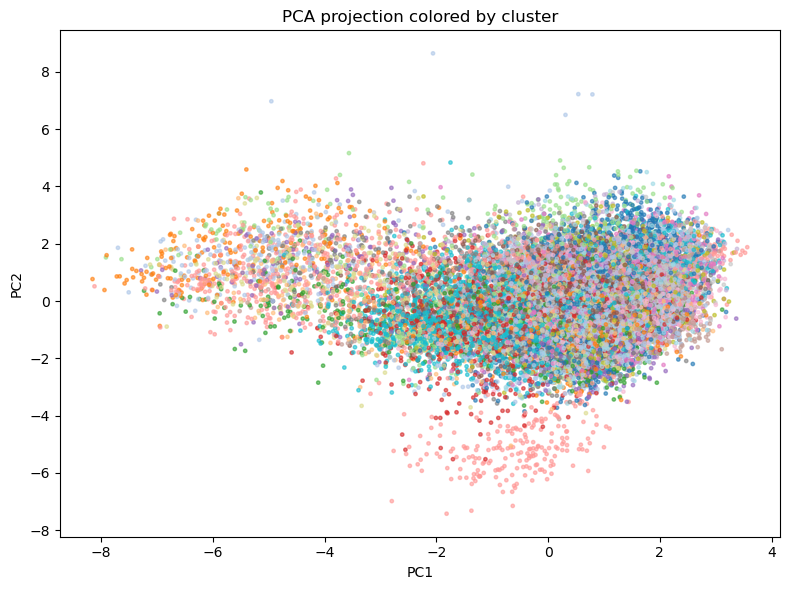

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

n_samples = X_main.shape[0]
max_sample = 20000

if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_vis, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection colored by cluster")
plt.tight_layout()
plt.show()

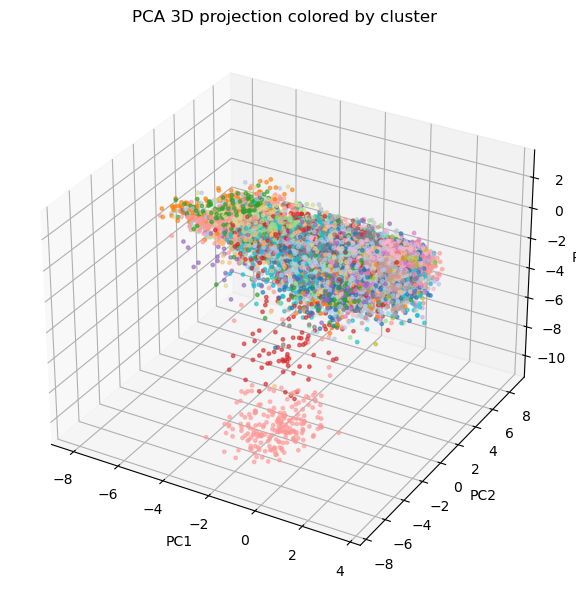

In [60]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  

n_samples = X_main.shape[0]
max_sample = 20000
if n_samples > max_sample:
    rng = np.random.RandomState(RANDOM_STATE)
    vis_indices = rng.choice(n_samples, size=max_sample, replace=False)
else:
    vis_indices = np.arange(n_samples)

X_vis = X_main[vis_indices]
clusters_vis = full_df.loc[vis_indices, "cluster_kmeans_main"].to_numpy()

pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca3.fit_transform(X_vis)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=clusters_vis, s=6, alpha=0.6, cmap="tab20")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA 3D projection colored by cluster")
plt.tight_layout()
plt.show()


## 3.8 t-SNE

We try to look at nonlinear local structure by using t-SNE on a smaller sample to inspect local neighborhoods. Expect some overlap; well-separated islands suggest stronger local consistency. 

t-SNE sample size: 10000, perplexity: 30
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 0.001s...
[t-SNE] Computed neighbors for 10000 samples in 0.297s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 2.402167
[t-SNE] KL divergence after 250 iterations with early exaggeration: 86.305634
[t-SNE] KL divergence after 1000 itera

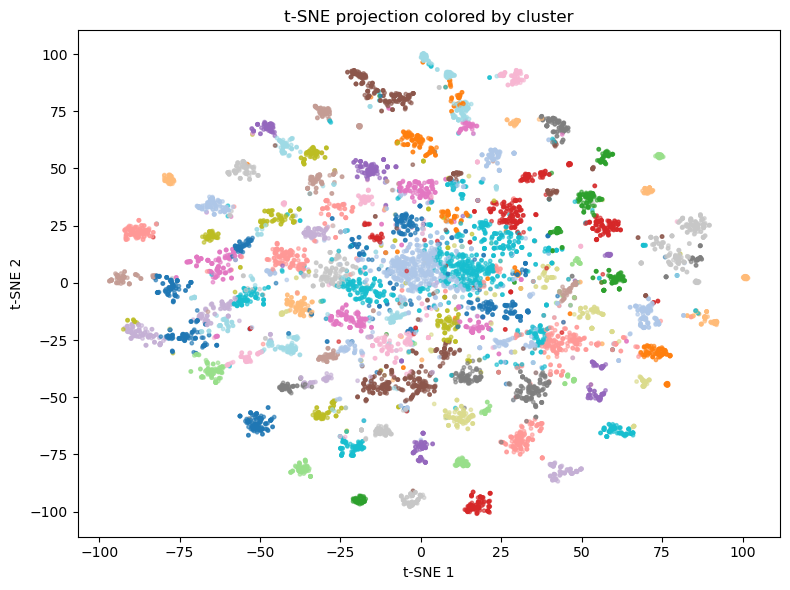

In [61]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

max_tsne = 10000

if n_samples > max_tsne:
    rng = np.random.RandomState(RANDOM_STATE)
    tsne_indices = rng.choice(n_samples, size=max_tsne, replace=False)
else:
    tsne_indices = np.arange(n_samples)

X_tsne_in = X_main[tsne_indices]
clusters_tsne = full_df.loc[tsne_indices, "cluster_kmeans_main"].to_numpy()

n_tsne = len(tsne_indices)
if n_tsne <= 10:
    raise ValueError(f"Not enough samples for t-SNE (got {n_tsne})")
perplexity = min(30, max(5, n_tsne // 3))
if perplexity >= n_tsne:
    perplexity = max(5, n_tsne - 1)

print(f"t-SNE sample size: {n_tsne}, perplexity: {perplexity}")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=200,
    metric="euclidean",
    init="random",
    random_state=RANDOM_STATE,
    verbose=1,
)

X_tsne = tsne.fit_transform(X_tsne_in)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_tsne, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE projection colored by cluster")
plt.tight_layout()
plt.show()

## 3.9 UMAP

We use UMAP to look at more nonlinear both global and local structure. Alternative nonlinear 2D view that balances global and local structure. We compare its layout to t-SNE to see if clusters separate more clearly.

/Users/andreas/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


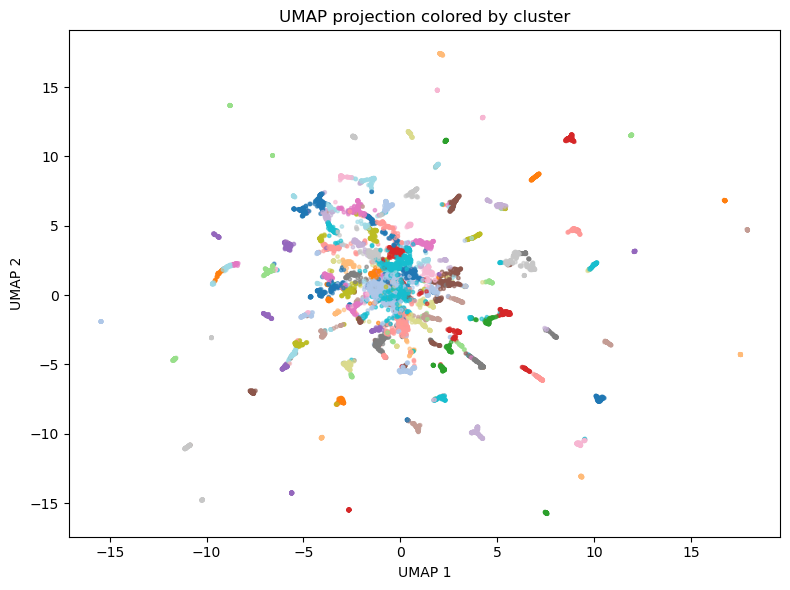

In [62]:
import umap
import matplotlib.pyplot as plt

max_umap = 10000
if X_main.shape[0] > max_umap:
    rng = np.random.RandomState(RANDOM_STATE)
    umap_indices = rng.choice(X_main.shape[0], size=max_umap, replace=False)
else:
    umap_indices = np.arange(X_main.shape[0])

X_umap_in = X_main[umap_indices]
clusters_umap = full_df.loc[umap_indices, "cluster_kmeans_main"].to_numpy()

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=25,
    min_dist=0.15,
    metric="euclidean",
    random_state=RANDOM_STATE,
)
X_umap = reducer.fit_transform(X_umap_in)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=clusters_umap, s=6, alpha=0.6, cmap="tab20")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP projection colored by cluster")
plt.tight_layout()
plt.show()


## 3.10 LSH recall and latency check

Evaluate the cosine LSH built in part 2 against exact neighbours. We sample a subset of queries,
compare to brute-force KNN, and sweep a few table/bit settings to see the speed/quality trade-off.


In [63]:
from collections import defaultdict
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_distances
import time

# Locate LSH signatures (generated in part 2)
lsh_candidates = [
    artifact_dir / "lsh_signatures.npz",
    project_root / "main" / "artifacts" / "lsh_signatures.npz",
]
lsh_path = next((p for p in lsh_candidates if p.exists()), None)
if lsh_path is None:
    raise FileNotFoundError('Could not find lsh_signatures.npz in artifacts folders')

lsh_npz = np.load(lsh_path)
lsh_bits = lsh_npz['lsh_bits']  
n_tables = int(lsh_npz['n_tables'])
n_bits_per_table = int(lsh_npz['n_bits_per_table'])
bits_table = lsh_bits.reshape(lsh_bits.shape[0], n_tables, n_bits_per_table)

# Align signatures to the same row order as X_main / full_df
bits_table = bits_table[row_order]
bits_table.shape


(55129, 8, 16)

In [64]:
# Ground-truth neighbors via exact brute-force KNN
rng = np.random.RandomState(RANDOM_STATE)
n_eval = 1000  
k_eval = 10
query_indices = rng.choice(X_main.shape[0], size=n_eval, replace=False)

knn_exact = NearestNeighbors(metric='cosine', algorithm='brute')
knn_exact.fit(X_main)
gt_dists, gt_indices = knn_exact.kneighbors(X_main[query_indices], n_neighbors=k_eval + 1)

gt_neighbors = []
for q_idx, inds in zip(query_indices, gt_indices):
    filtered = [i for i in inds if i != q_idx]
    gt_neighbors.append(np.array(filtered[:k_eval]))
gt_neighbors = np.vstack(gt_neighbors)
gt_lookup = {q: set(neigh.tolist()) for q, neigh in zip(query_indices, gt_neighbors)}
len(gt_lookup)


1000

In [65]:
def build_bucket_maps(bits_table, tables_used, bits_used):
    """Create bucket dictionaries for each table using the first bits_used bits.
    Returns a list of dicts keyed by signature tuple -> list of indices."""
    bucket_maps = []
    for t in range(tables_used):
        buckets = defaultdict(list)
        table_bits = bits_table[:, t, :bits_used]
        for idx, sig in enumerate(table_bits):
            buckets[tuple(sig.tolist())].append(idx)
        bucket_maps.append(buckets)
    return bucket_maps

def evaluate_lsh_config(tables_used, bits_used, k=k_eval):
    bits_used = min(bits_used, n_bits_per_table)
    bucket_maps = build_bucket_maps(bits_table, tables_used, bits_used)

    recalls, precisions, cand_counts = [], [], []
    t0 = time.perf_counter()
    for q_idx in query_indices:
        candidates = set()
        for t, buckets in enumerate(bucket_maps):
            key = tuple(bits_table[q_idx, t, :bits_used].tolist())
            candidates.update(buckets.get(key, []))
        candidates.discard(q_idx)
        cand_counts.append(len(candidates))
        if not candidates:
            recalls.append(0.0)
            precisions.append(0.0)
            continue

        cand_arr = np.fromiter(candidates, dtype=int)
        dists = cosine_distances(X_main[q_idx:q_idx + 1], X_main[cand_arr]).ravel()
        order = np.argsort(dists)[:k]
        retrieved = cand_arr[order]

        retrieved_set = set(retrieved.tolist())
        gt_set = gt_lookup[q_idx]
        hits = len(retrieved_set & gt_set)

        recalls.append(hits / len(gt_set))
        precisions.append(hits / len(retrieved_set))

    t1 = time.perf_counter()
    return {
        'tables': tables_used,
        'bits': bits_used,
        'recall_mean': float(np.mean(recalls)),
        'recall_std': float(np.std(recalls)),
        'precision_mean': float(np.mean(precisions)),
        'cand_mean': float(np.mean(cand_counts)),
        'cand_median': float(np.median(cand_counts)),
        'cand_p95': float(np.percentile(cand_counts, 95)),
        'query_ms': (t1 - t0) / len(query_indices) * 1e3,
    }

base_lsh_metrics = evaluate_lsh_config(tables_used=n_tables, bits_used=n_bits_per_table)
base_lsh_metrics


{'tables': 8,
 'bits': 16,
 'recall_mean': 0.6612,
 'recall_std': 0.3184565276454543,
 'precision_mean': 0.6639857142857143,
 'cand_mean': 71.507,
 'cand_median': 50.0,
 'cand_p95': 194.4499999999996,
 'query_ms': 0.3017872909549624}

In [66]:
tables_grid = [2, 4, 6, 8]
bits_grid = [8, 12, 16]
grid_results = []
for t in tables_grid:
    for b in bits_grid:
        grid_results.append(evaluate_lsh_config(tables_used=t, bits_used=b))

grid_df = (
    pd.DataFrame(grid_results)
    .sort_values(['recall_mean', 'query_ms'], ascending=[False, True])
    .reset_index(drop=True)
)
grid_df


,tables,bits,recall_mean,recall_std,precision_mean,cand_mean,cand_median,cand_p95,query_ms
0,8,8,0.9153,0.169162,0.915300,2098.390,2039.0,2884.95,1.865247
1,6,8,0.8784,0.202122,0.878400,1618.778,1560.0,2384.50,2.263049
2,4,8,0.7998,0.252507,0.799800,1094.014,1057.5,1669.25,1.025117
3,8,12,0.7875,0.266822,0.787500,262.325,235.0,493.05,0.509987
4,6,12,0.7296,0.289627,0.729600,209.651,180.0,408.05,0.428946
5,8,16,0.6612,0.318457,0.663986,71.507,50.0,194.45,0.379911
6,4,12,0.6375,0.315791,0.637500,140.630,123.0,297.00,1.601903
7,2,8,0.6359,0.319220,0.635900,560.357,526.0,957.35,1.161280
8,6,16,0.6008,0.329635,0.609931,58.556,38.0,170.05,0.374740
9,4,16,0.5073,0.337604,0.538629,41.699,27.0,131.00,0.788336


## 3.11 LSH recall vs speed plots

Scatter plots to visualize the trade-offs across configurations: higher recall generally comes with larger candidate sets and slower queries.


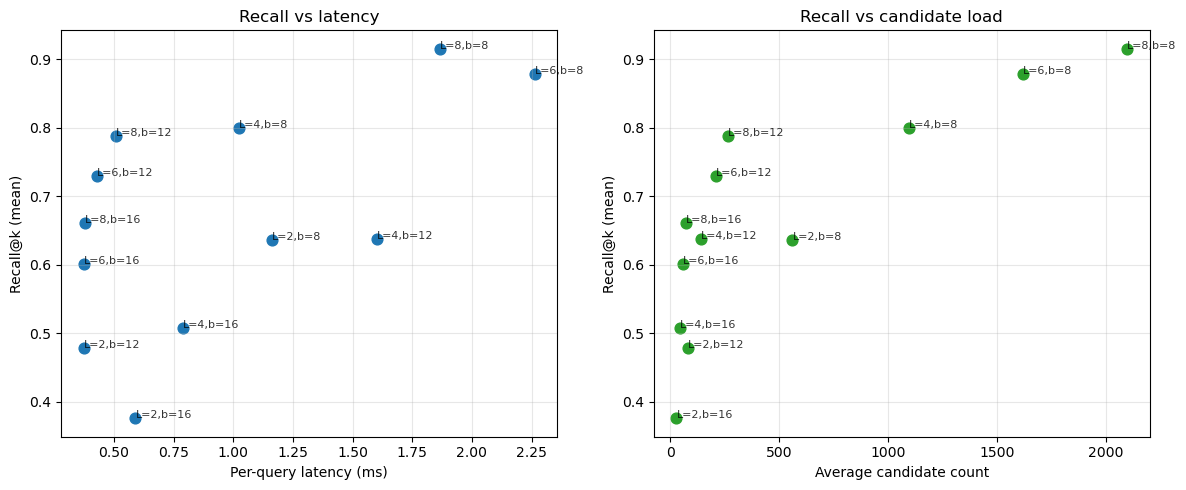

In [67]:
import matplotlib.pyplot as plt

def plot_lsh_grid(df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Recall vs latency
    ax = axes[0]
    ax.scatter(df['query_ms'], df['recall_mean'], s=60, color='tab:blue')
    for _, row in df.iterrows():
        ax.annotate(f"L={int(row.tables)},b={int(row.bits)}", (row.query_ms, row.recall_mean), fontsize=8, alpha=0.8)
    ax.set_xlabel('Per-query latency (ms)')
    ax.set_ylabel('Recall@k (mean)')
    ax.set_title('Recall vs latency')
    ax.grid(True, alpha=0.3)

    # Recall vs candidate load
    ax = axes[1]
    ax.scatter(df['cand_mean'], df['recall_mean'], s=60, color='tab:green')
    for _, row in df.iterrows():
        ax.annotate(f"L={int(row.tables)},b={int(row.bits)}", (row.cand_mean, row.recall_mean), fontsize=8, alpha=0.8)
    ax.set_xlabel('Average candidate count')
    ax.set_ylabel('Recall@k (mean)')
    ax.set_title('Recall vs candidate load')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

plot_lsh_grid(grid_df);


## 3.12 Conclusion

Clustering recap: Silhouette (~0.33 with cosine) and purity/NMI/ARI (0.47/0.58/0.23) indicate moderate but meaningful separation: most tracks have clearly positive silhouettes (median ~0.36, 75% ~0.58) with a small negative tail down to ~–0.93, so clusters are real but still overlapping and fuzzy at the boundaries. PCA/t-SNE/UMAP and tag/exemplar inspection show both compact pockets (sleep, ambient, punk) and broader blended regions (high-energy party/Brazil). Cluster summaries highlight size imbalances and contrasting feature profiles (energy, acousticness, valence), giving us enough structure for coarse recommendation buckets but not for strict genre labeling.

LSH recall/latency (recall@10 vs exact cosine, ~1k queries):
- 8 tables × 8 bits: ~0.92 recall/precision, ~2.1k candidates, ~2.7 ms/query (highest quality, heaviest scan).
- 8 × 12: ~0.79 recall, ~260 candidates, ~1.0 ms (balanced default).
- 8 × 16: ~0.66 recall, ~72 candidates, ~0.6 ms (latency-first).

Best is probably to keep 8 × 12 as the default speed/quality trade. Move up to 8 × 8 when you need higher recall and can afford larger candidate sets; drop to 8 × 16 when sub-millisecond latency matters more than recall.

